<h2 style="text-align: center;" markdown="1">EEIF Research Education</h2>
<h3 style="text-align: center;" markdown="1">Intro to Data Visualization</h2>

In [ ]:
# Import relevant libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### Data Simulation

In [2]:
np.random.seed(42)
n = 200

# Exogenous variables
income = np.random.normal(60_000, 10_000, n)          # household income
adv = np.random.uniform(0, 100, n)                    # advertising intensity
comp_price = np.random.uniform(8, 15, n)              # competitor price

# Endogenous price (positively correlated with unobservables)
u = np.random.normal(0, 4, n)                         # demand shock
price = 20 - 0.0001*income + 0.05*adv + 0.3*u + np.random.normal(0, 1, n)

# Demand equation (true DGP)
quantity = 200 - 3.2*price + 0.5*adv + 0.0008*income + 1.5*comp_price + u

df = pd.DataFrame({
    "quantity": quantity,
    "price": price,
    "advertising": adv,
    "income": income,
    "competitor_price": comp_price
})

df.to_csv("simulated_market_data.csv", index=False)
display(df.head())

,quantity,price,advertising,income,competitor_price
0,265.573805,15.552751,87.737307,64967.141530,14.735208
1,240.756542,17.863567,74.076862,58617.356988,10.624094
2,253.155215,14.846088,69.701574,66476.885381,9.999985
3,259.509104,16.707396,70.248408,75230.298564,14.080194
4,233.817875,14.007906,35.949115,57658.466253,9.565171


In [3]:
# Data cleaning 
df.isna().sum()

quantity            0
price               0
advertising         0
income              0
competitor_price    0
dtype: int64

In [4]:
df.describe()

,quantity,price,advertising,income,competitor_price
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,236.481534,16.571737,49.632449,59592.290348,11.516792
std,14.690522,2.329926,29.658749,9310.039152,2.061548
min,202.274413,8.442020,1.083765,33802.548959,8.085081
25%,227.241523,14.899253,24.961492,52948.723251,9.722901
50%,236.360565,16.605802,51.382137,59958.081160,11.506508
75%,246.464411,17.990461,75.262544,65008.524730,13.249854
max,273.957923,22.295706,99.050514,87201.691666,14.998024


In [5]:
df.corr()

,quantity,price,advertising,income,competitor_price
quantity,1.000000,0.059649,0.649260,0.675498,0.136049
price,0.059649,1.000000,0.619029,-0.406355,0.064493
advertising,0.649260,0.619029,1.000000,-0.035785,-0.059379
income,0.675498,-0.406355,-0.035785,1.000000,-0.056478
competitor_price,0.136049,0.064493,-0.059379,-0.056478,1.000000


### Data Visualization

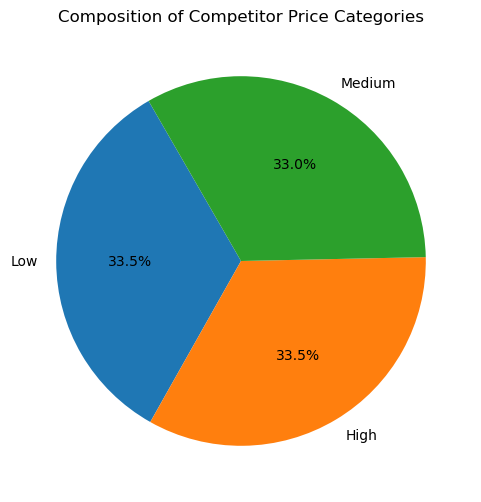

In [6]:
df["comp_price_bin"] = pd.qcut(df["competitor_price"], 3, labels=["Low","Medium","High"])

comp_counts = df["comp_price_bin"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    comp_counts.values, 
    labels=comp_counts.index, 
    autopct="%1.1f%%",
    startangle=120
)
plt.title("Composition of Competitor Price Categories")
plt.show()

/var/folders/07/l8m36_9s2lz170jptjv7r6jc0000gn/T/ipykernel_5397/2051543633.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_q = df.groupby("income_q")["quantity"].mean().reset_index()


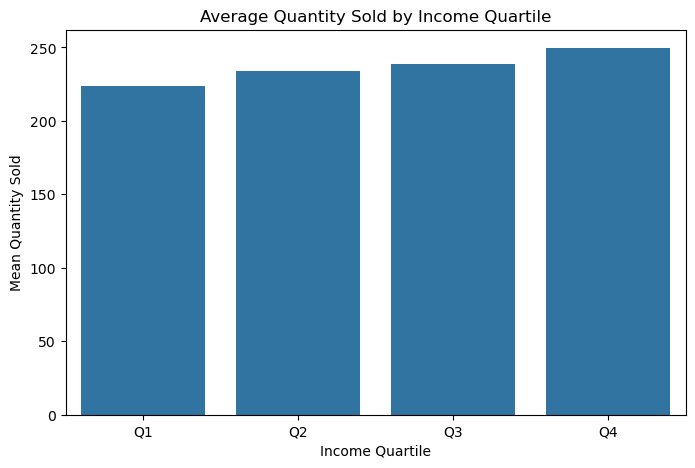

In [7]:
df["income_q"] = pd.qcut(df["income"], 4, labels=["Q1","Q2","Q3","Q4"])
avg_q = df.groupby("income_q")["quantity"].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=avg_q, x="income_q", y="quantity")
plt.title("Average Quantity Sold by Income Quartile")
plt.xlabel("Income Quartile")
plt.ylabel("Mean Quantity Sold")
plt.show()

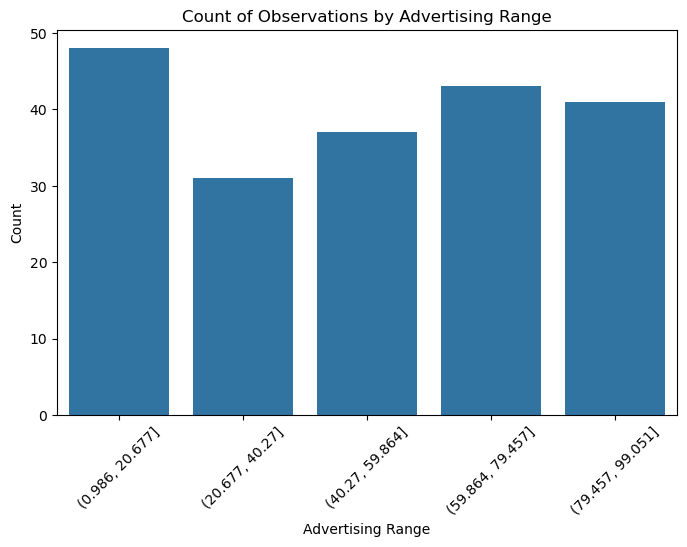

In [8]:
df["adv_bin"] = pd.cut(df["advertising"], bins=5)

plt.figure(figsize=(8,5))
sns.countplot(data=df, x="adv_bin")
plt.title("Count of Observations by Advertising Range")
plt.xlabel("Advertising Range")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

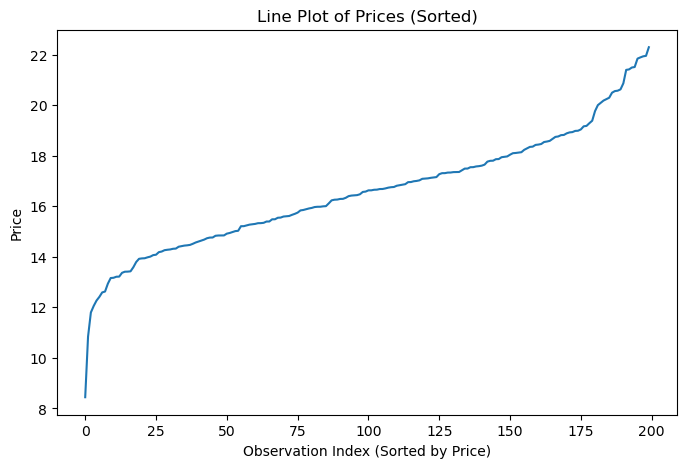

In [9]:
df_sorted = df.sort_values("price").reset_index(drop=True)

plt.figure(figsize=(8,5))
plt.plot(df_sorted["price"])
plt.title("Line Plot of Prices (Sorted)")
plt.xlabel("Observation Index (Sorted by Price)")
plt.ylabel("Price")
plt.show()

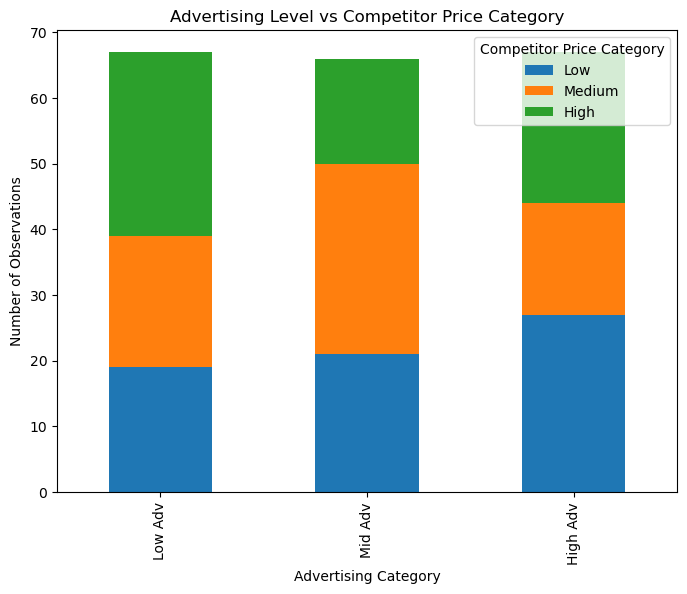

In [10]:
adv_cat = pd.qcut(df["advertising"], 3, labels=["Low Adv", "Mid Adv", "High Adv"])
price_cat = df["comp_price_bin"]

cross_tab = pd.crosstab(adv_cat, price_cat)

cross_tab.plot(
    kind="bar",
    stacked=True,
    figsize=(8,6)
)

plt.title("Advertising Level vs Competitor Price Category")
plt.xlabel("Advertising Category")
plt.ylabel("Number of Observations")
plt.legend(title="Competitor Price Category")
plt.show()

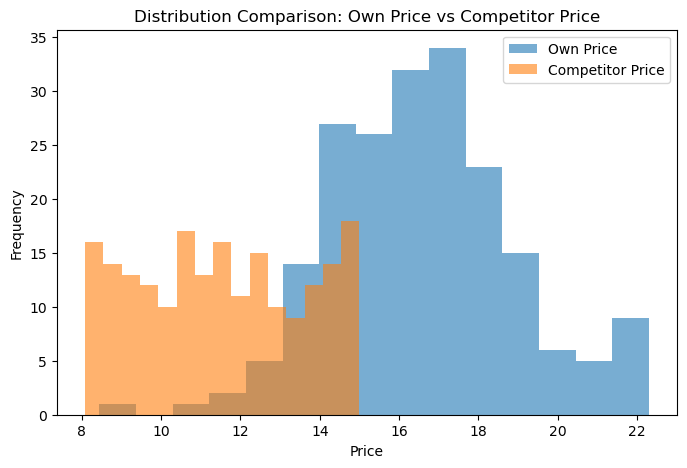

In [11]:
plt.figure(figsize=(8,5))
plt.hist(df["price"], alpha=0.6, bins=15, label="Own Price")
plt.hist(df["competitor_price"], alpha=0.6, bins=15, label="Competitor Price")
plt.title("Distribution Comparison: Own Price vs Competitor Price")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.legend()
plt.show()

/var/folders/07/l8m36_9s2lz170jptjv7r6jc0000gn/T/ipykernel_5397/1027210011.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby("price_bin")["quantity"].agg(["mean","sem"]).reset_index()


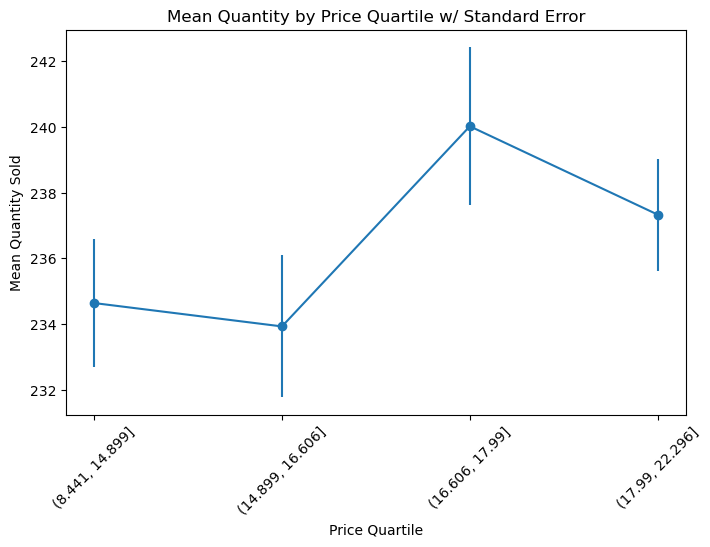

In [12]:
df["price_bin"] = pd.qcut(df["price"], 4)

grouped = df.groupby("price_bin")["quantity"].agg(["mean","sem"]).reset_index()

plt.figure(figsize=(8,5))
plt.errorbar(
    x=grouped["price_bin"].astype(str),
    y=grouped["mean"],
    yerr=grouped["sem"],
    fmt="o-"
)
plt.title("Mean Quantity by Price Quartile w/ Standard Error")
plt.xlabel("Price Quartile")
plt.ylabel("Mean Quantity Sold")
plt.xticks(rotation=45)
plt.show()

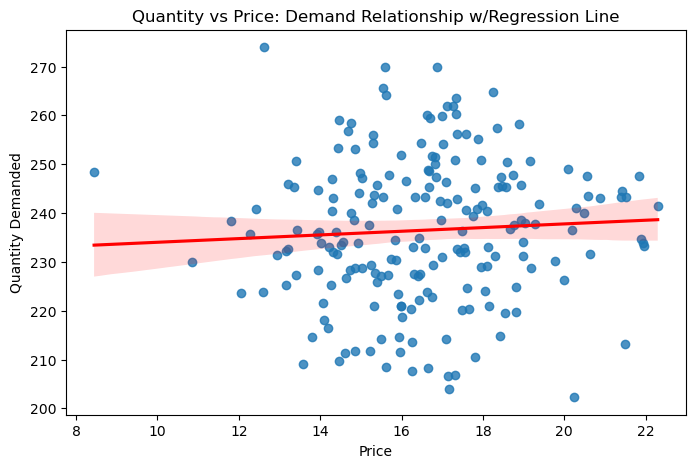

In [13]:
plt.figure(figsize=(8,5))
sns.regplot(data=df, x="price", y="quantity", line_kws={"color": "red"})
plt.title("Quantity vs Price: Demand Relationship w/Regression Line")
plt.xlabel("Price")
plt.ylabel("Quantity Demanded")
plt.show()

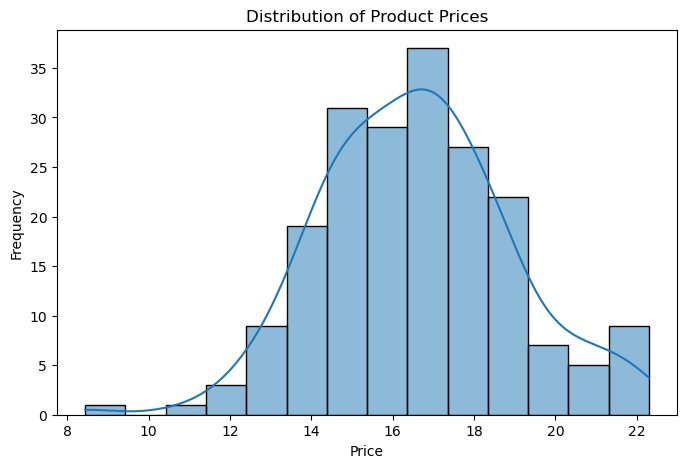

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(df["price"], kde=True)
plt.title("Distribution of Product Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

In [16]:
plt.figure(figsize=(9,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()


ValueError: could not convert string to float: 'High'

<Figure size 900x600 with 0 Axes>

<Figure size 1000x1000 with 0 Axes>

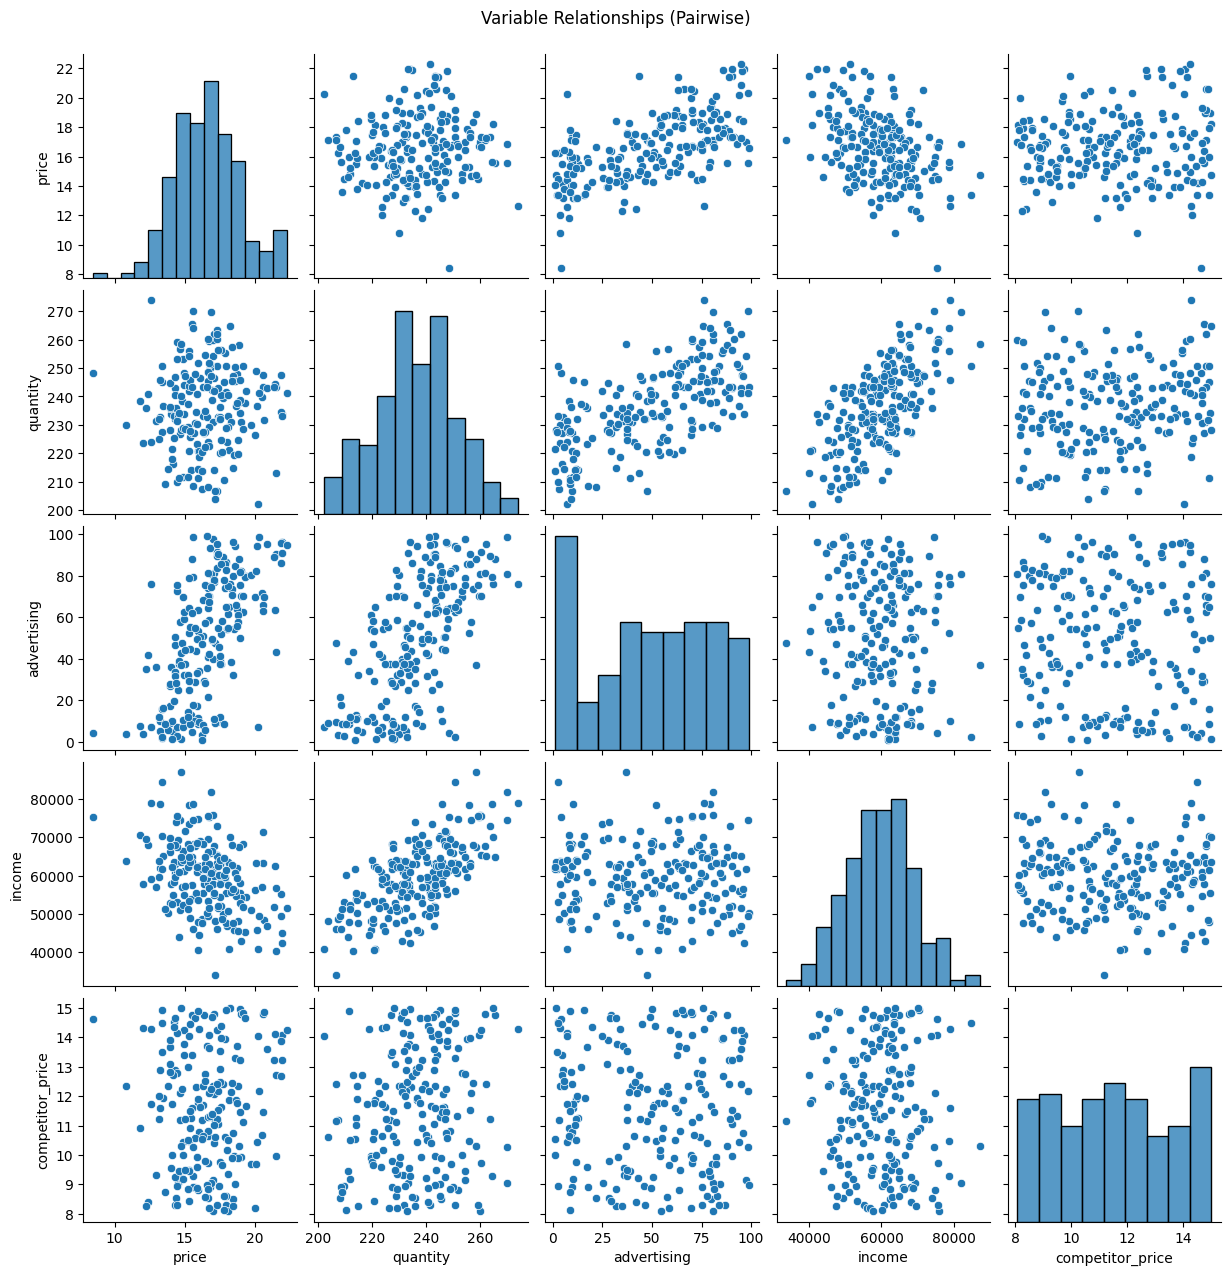

In [ ]:
plt.figure(figsize=(10,10))
sns.pairplot(df[["price","quantity","advertising","income","competitor_price"]])
plt.suptitle("Variable Relationships (Pairwise)", y=1.02)
plt.show()

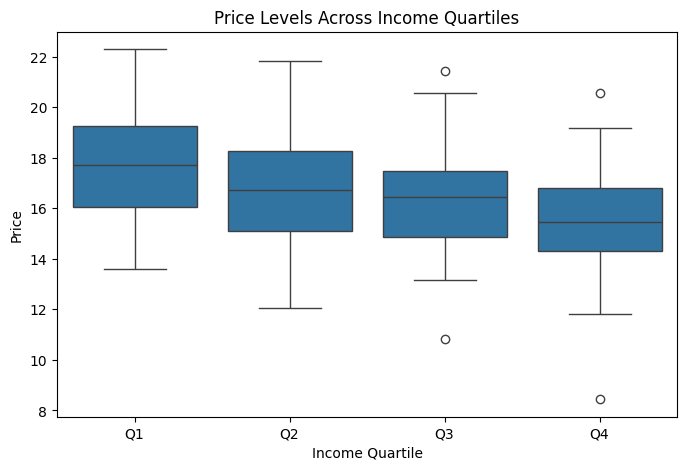

In [ ]:
df["income_q"] = pd.qcut(df["income"], 4, labels=["Q1","Q2","Q3","Q4"])

plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="income_q", y="price")
plt.title("Price Levels Across Income Quartiles")
plt.xlabel("Income Quartile")
plt.ylabel("Price")
plt.show()

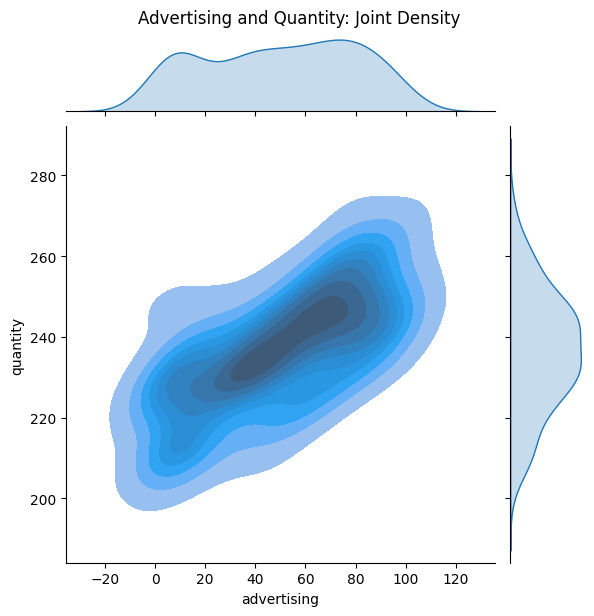

In [ ]:
sns.jointplot(
    data=df,
    x="advertising",
    y="quantity",
    kind="kde",
    fill=True,
    height=6
)
plt.suptitle("Advertising and Quantity: Joint Density", y=1.02)
plt.show()

### Linear Regression

In [ ]:
import statsmodels.api as sm
X = df[["price", "advertising", "income", "competitor_price"]]
X = sm.add_constant(X)
y = df["quantity"]

model = sm.OLS(y, X).fit()
display(model.summary())

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               quantity   R-squared:                       0.975
Model:                            OLS   Adj. R-squared:                  0.974
Method:                 Least Squares   F-statistic:                     2038.
Date:                Fri, 14 Nov 2025   Prob (F-statistic):          8.27e-158
Time:                        07:34:01   Log-Likelihood:                -452.16
No. Observations:                 200   AIC:                             914.3
Df Residuals:                     195   BIC:                             930.8
Df Model:                           4                                         
Covariance Type:                  HC1                                         
====================================================================================
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const              158.0035      2.507     63.026      0.000     153.090     162.917
price               -1.2338      0.108    -11.444      0.000      -1.445      -1.022
advertising          0.3997      0.007     56.012      0.000       0.386       0.414
income               0.0010   1.95e-05     51.628      0.000       0.001       0.001
competitor_price     1.6577      0.089     18.730      0.000       1.484       1.831
==============================================================================
Omnibus:                        3.771   Durbin-Watson:                   1.931
Prob(Omnibus):                  0.152   Jarque-Bera (JB):                2.680
Skew:                          -0.119   Prob(JB):                        0.262
Kurtosis:                       2.485   Cond. No.                     9.05e+05
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
[2] The condition number is large, 9.05e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [ ]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression().fit(df[["price","advertising","income","competitor_price"]], y)
print(reg.coef_, reg.intercept_)

[-1.23375675e+00  3.99737821e-01  1.00671845e-03  1.65765550e+00] 158.003526683618


In [ ]:
from sklearn.linear_model import Lasso, Ridge

lasso = Lasso(alpha=0.1).fit(X.drop(columns="const"), y)
ridge = Ridge(alpha=1.0).fit(X.drop(columns="const"), y)
print(lasso.coef_, lasso.intercept_)
print(ridge.coef_, ridge.intercept_)

[-1.18821442e+00  3.97338347e-01  1.01072500e-03  1.62966030e+00] 157.45155842578325
[-1.23095948e+00  3.99593028e-01  1.00695860e-03  1.65543181e+00] 157.97565620954347


In [ ]:
from statsmodels.sandbox.regression.gmm import IV2SLS

# --- Instrument creation ---
cost_shock = np.random.normal(0, 2, n)
df["instrument"] = df["competitor_price"] + 0.5 * cost_shock

# --- Dependent variable ---
y = df["quantity"]

# --- Regressors: include BOTH exogenous + endogenous --- 
# Order does not matter as long as the instrument matrix matches
X = df[["price", "advertising", "income", "competitor_price"]]
X = sm.add_constant(X)

# --- Instruments: include exogenous + actual instrument(s) ---
Z = df[["instrument", "advertising", "income", "competitor_price"]]
Z = sm.add_constant(Z)

# --- Estimate IV ---
iv_model = IV2SLS(y, X, Z).fit()

display(iv_model.summary())

<class 'statsmodels.iolib.summary.Summary'>
"""
                          IV2SLS Regression Results                           
==============================================================================
Dep. Variable:               quantity   R-squared:                       0.974
Model:                         IV2SLS   Adj. R-squared:                  0.974
Method:                     Two Stage   F-statistic:                     1799.
                        Least Squares   Prob (F-statistic):          1.16e-152
Date:                Fri, 14 Nov 2025                                         
Time:                        07:38:29                                         
No. Observations:                 200                                         
Df Residuals:                     195                                         
Df Model:                           4                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const              152.8783     24.563      6.224      0.000     104.435     201.321
price               -0.9616      1.302     -0.739      0.461      -3.529       1.606
advertising          0.3867      0.063      6.171      0.000       0.263       0.510
income               0.0010      0.000      8.250      0.000       0.001       0.001
competitor_price     1.6333      0.143     11.434      0.000       1.352       1.915
==============================================================================
Omnibus:                        4.668   Durbin-Watson:                   1.928
Prob(Omnibus):                  0.097   Jarque-Bera (JB):                3.260
Skew:                          -0.157   Prob(JB):                        0.196
Kurtosis:                       2.459   Cond. No.                     9.05e+05
==============================================================================
"""

<hr />
<p style="font-family:palatino; text-align: center;font-size: 15px">EEIF Quantitative Research Team</a></p>
<p style="font-family:palatino; text-align: center;font-size: 15px"><em>Jiuyi (Joy) Cheng</em></a></p>
<p style="font-family:palatino; text-align: center;font-size: 15px">Emory University, Department of Economics</a></p>


## Educational Visualization Walkthrough

This section uses the simulated market dataset to show how to move from raw rows to clear visual stories. Each cell adds one small idea: inspect the data, check quality, visualize distributions, and compare relationships.

In [21]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")

data_candidates = [
    Path("simulated_market_data.csv"),
    Path("project_team/simulated_market_data.csv"),
]

for candidate in data_candidates:
    if candidate.exists():
        data_path = candidate
        break
else:
    raise FileNotFoundError("Could not find simulated_market_data.csv in the expected locations.")

df = pd.read_csv(data_path)
df

,quantity,price,advertising,income,competitor_price
0,265.573805,15.552751,87.737307,64967.141530,14.735208
1,240.756542,17.863567,74.076862,58617.356988,10.624094
2,253.155215,14.846088,69.701574,66476.885381,9.999985
3,259.509104,16.707396,70.248408,75230.298564,14.080194
4,233.817875,14.007906,35.949115,57658.466253,9.565171
...,...,...,...,...,...
195,232.133146,13.169954,11.881792,63853.173797,11.995448
196,211.772314,15.212894,11.752625,51161.425638,10.492677
197,250.779807,17.957799,64.921030,61537.251059,14.905607
198,247.373421,16.855548,74.604488,60582.087184,12.240424


### 1. Quick inspection

Before drawing any chart, it helps to see the first few rows and basic dimensions of the dataset.

In [18]:
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
display(df.head())
display(df.describe().T)

Rows: 200, Columns: 5


,quantity,price,advertising,income,competitor_price
0,265.573805,15.552751,87.737307,64967.141530,14.735208
1,240.756542,17.863567,74.076862,58617.356988,10.624094
2,253.155215,14.846088,69.701574,66476.885381,9.999985
3,259.509104,16.707396,70.248408,75230.298564,14.080194
4,233.817875,14.007906,35.949115,57658.466253,9.565171


,count,mean,std,min,25%,50%,75%,max
quantity,200.0,236.481534,14.690522,202.274413,227.241523,236.360565,246.464411,273.957923
price,200.0,16.571737,2.329926,8.442020,14.899253,16.605802,17.990461,22.295706
advertising,200.0,49.632449,29.658749,1.083765,24.961492,51.382137,75.262544,99.050514
income,200.0,59592.290348,9310.039152,33802.548959,52948.723251,59958.081160,65008.524730,87201.691666
competitor_price,200.0,11.516792,2.061548,8.085081,9.722901,11.506508,13.249854,14.998024


### 2. Missing values and data quality

A simple completeness check helps students understand whether a chart is trustworthy or needs cleaning first.

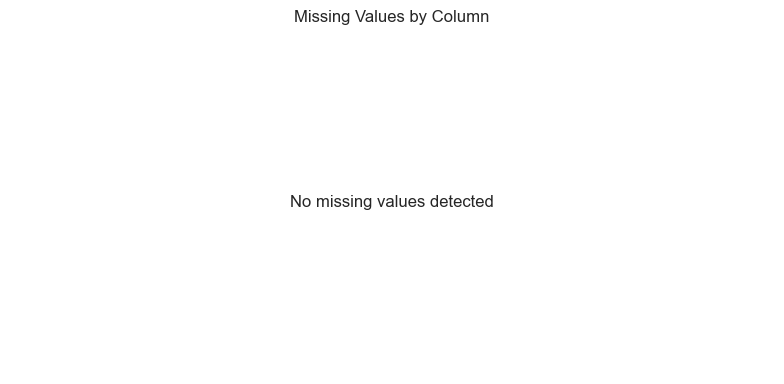

In [19]:
missing = df.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]

plt.figure(figsize=(8, 4))
if missing.empty:
    plt.title("Missing Values by Column")
    plt.text(0.5, 0.5, "No missing values detected", ha="center", va="center", fontsize=12)
    plt.axis("off")
else:
    sns.barplot(x=missing.index, y=missing.values, color="#4C72B0")
    plt.title("Missing Values by Column")
    plt.ylabel("Count")
    plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

### 3. Distribution of each numeric variable

Histograms show the shape of the data: center, spread, and whether the values are skewed.

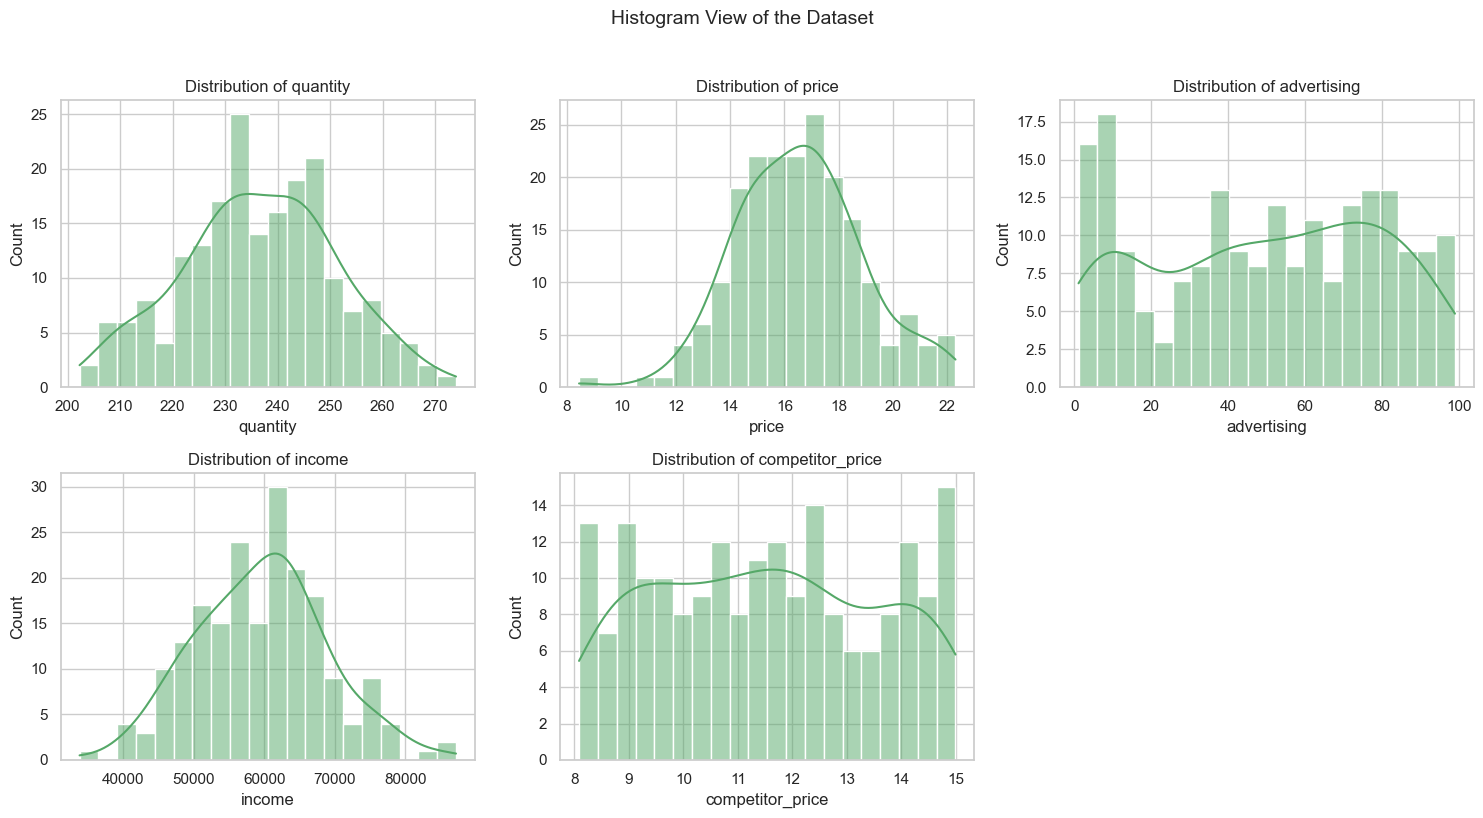

In [20]:
numeric_cols = df.select_dtypes(include="number").columns.tolist()
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 8))
axes = axes.flatten()

for ax, column in zip(axes, numeric_cols):
    sns.histplot(df[column], kde=True, ax=ax, color="#55A868", bins=20)
    ax.set_title(f"Distribution of {column}")
    ax.set_xlabel(column)
    ax.set_ylabel("Count")

for ax in axes[len(numeric_cols):]:
    ax.axis("off")

fig.suptitle("Histogram View of the Dataset", y=1.02, fontsize=14)
fig.tight_layout()
plt.show()

### 4. Relationship between advertising and quantity

Scatter plots are useful for seeing whether one variable tends to move with another.

In [ ]:
plt.figure(figsize=(9, 6))
sns.regplot(
    data=df,
    x="advertising",
    y="quantity",
    scatter_kws={"alpha": 0.7, "color": "#4C72B0"},
    line_kws={"color": "#DD8452", "linewidth": 2},
)
plt.title("Advertising vs Quantity")
plt.xlabel("Advertising Spend")
plt.ylabel("Quantity")
plt.tight_layout()
plt.show()

### 5. Price versus quantity with income as a third signal

Color and size can add a third dimension without turning the chart into a table.

In [ ]:
plt.figure(figsize=(9, 6))
scatter = plt.scatter(
    df["price"],
    df["quantity"],
    c=df["income"],
    s=np.clip(df["advertising"], 10, None),
    cmap="viridis",
    alpha=0.75,
    edgecolor="white",
    linewidth=0.5,
)
plt.colorbar(scatter, label="Income")
plt.title("Price vs Quantity")
plt.xlabel("Price")
plt.ylabel("Quantity")
plt.tight_layout()
plt.show()

### 6. Correlation heatmap

Correlation summaries help students spot which variables move together before modeling.

In [ ]:
corr = df[numeric_cols].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

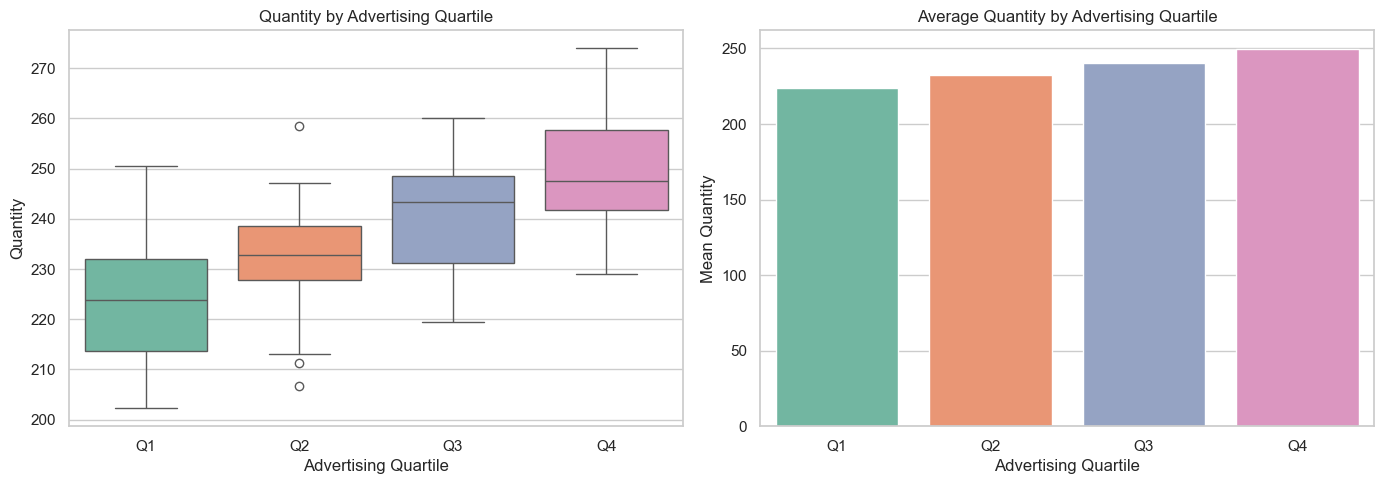

In [23]:
df["advertising_quartile"] = pd.qcut(df["advertising"], q=4, labels=["Q1", "Q2", "Q3", "Q4"])
summary_by_quartile = df.groupby("advertising_quartile", observed=True)["quantity"].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(
    data=df,
    x="advertising_quartile",
    y="quantity",
    hue="advertising_quartile",
    palette="Set2",
    dodge=False,
    ax=axes[0],
)
legend = axes[0].get_legend()
if legend is not None:
    legend.remove()
axes[0].set_title("Quantity by Advertising Quartile")
axes[0].set_xlabel("Advertising Quartile")
axes[0].set_ylabel("Quantity")

sns.barplot(
    data=summary_by_quartile,
    x="advertising_quartile",
    y="quantity",
    hue="advertising_quartile",
    palette="Set2",
    dodge=False,
    ax=axes[1],
)
legend = axes[1].get_legend()
if legend is not None:
    legend.remove()
axes[1].set_title("Average Quantity by Advertising Quartile")
axes[1].set_xlabel("Advertising Quartile")
axes[1].set_ylabel("Mean Quantity")

fig.tight_layout()
plt.show()